In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [2]:
label = LabelEncoder()

data = pd.read_csv("C:\\Users\\sulem\\OneDrive\\Desktop\\Codes\\ML\\Datasets\\Mall_Customers.csv")

def ColumnTransformation(data):

    data["Gender"] = label.fit_transform(data["Gender"])
    data = data.drop(columns=["CustomerID"])
    return data

Data = ColumnTransformation(data)
Data.sample(10)

Gender  Age  Annual Income (k$)  Spending Score (1-100)
23        1   31                  25                      73
139       0   35                  74                      72
78        0   23                  54                      52
111       0   19                  63                      54
109       1   66                  63                      48
198       1   32                 137                      18
97        0   27                  60                      50
116       0   63                  65                      43
96        0   47                  60                      47
125       0   31                  70                      77

[308862.06000000006, 212889.44245524294, 143391.5923603568, 104414.67534220168, 75399.61541401484, 58348.64136331505, 51130.69008126377, 44359.634641148325, 40887.36331763753, 37793.239213564215, 34891.12095682096, 32161.11834461835, 30064.428306878308, 28621.211280727068, 26239.530187758864, 25690.755624568665, 23560.91048510313, 22288.205994186974]


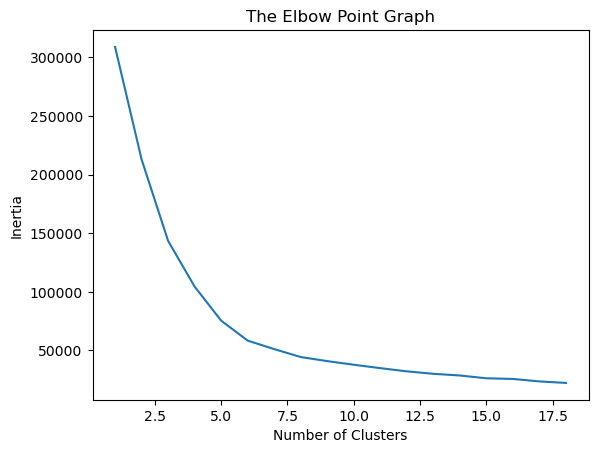

In [3]:
import warnings
warnings.filterwarnings('ignore')

inertia = []
for i in range(1,19):
    km = KMeans(n_clusters=i, n_init=10)
    km.fit_predict(Data) 
    inertia.append(km.inertia_)

print(inertia)

plt.plot(range(1,19), inertia)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [8]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=0) # K = 5 from Elbow Curve

Y = kmeans.fit_predict(Data)

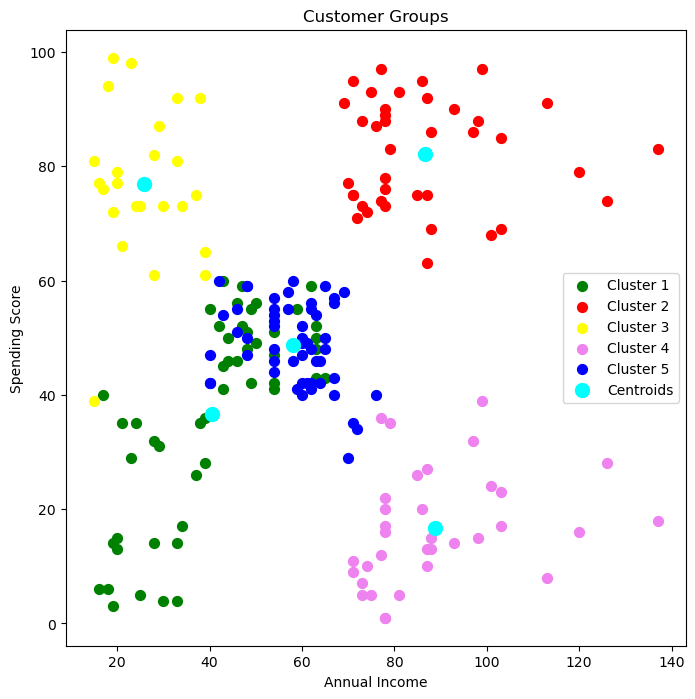

In [9]:
D = Data.values 

plt.figure(figsize=(8,8))
plt.scatter(D[Y==0, 2], D[Y==0, 3], s=50, c='green', label='Cluster 1')
plt.scatter(D[Y==1, 2], D[Y==1, 3], s=50, c='red', label='Cluster 2')
plt.scatter(D[Y==2, 2], D[Y==2, 3], s=50, c='yellow', label='Cluster 3')
plt.scatter(D[Y==3, 2], D[Y==3, 3], s=50, c='violet', label='Cluster 4')
plt.scatter(D[Y==4, 2], D[Y==4, 3], s=50, c='blue', label='Cluster 5')

plt.scatter(kmeans.cluster_centers_[:,2], kmeans.cluster_centers_[:,3], s=100, c='cyan', label='Centroids')

plt.title('Customer Groups')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()